# Spin polarization: LSDA

With `nspin = 2` the density, the potential, the eigenvalues and the wavefunctions all grow a
leading spin axis, and one self-consistent iteration diagonalises a *different Hamiltonian
per channel*. What couples them is the exchange-correlation functional, and the Fermi level,
which is **one** number shared by both unless `tot_magnetization` fixes the imbalance.

The density is a pair, and the moment is the integral of its difference:

$$n_\sigma(\mathbf r) = \sum_{n\mathbf k} f_{n\mathbf k\sigma}\,
   |\psi_{n\mathbf k\sigma}(\mathbf r)|^2,
\qquad
M = \int \big(n_\uparrow - n_\downarrow\big)\, d\mathbf r$$

The two channels see different potentials,
$v_{xc}^\sigma = \delta E_{xc}[n_\uparrow, n_\downarrow] / \delta n_\sigma$, and that
difference is the whole of band magnetism.

| against `pw.x` | defumat | `pw.x` |
|---|---|---|
| fcc nickel, total energy | **-85.723399012 Ry** | -85.72339901, 1.9e-9 apart |
| its magnetization | **0.7280 $\mu_B$** | 0.73, the two decimals it prints |
| an oxygen atom, total energy | **-31.404683565 Ry** | -31.40468356, 4.8e-9 apart |
| its magnetization | **2.0000 $\mu_B$** | 2.0, fixed by the input |

`starting_magnetization` only seeds the first density. What the loop converges to is whatever
balance of the two channels minimises the energy at one shared Fermi level, and for fcc
nickel that is a number the calculation **produces** rather than reproduces. Nothing forces
it to be non-zero: an unpolarized solution exists and is a stationary point too, only a
higher one.

In [1]:
import warnings
from pathlib import Path

from defumat import Calculator
from defumat.units import RY_TO_EV

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite")
CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")
warnings.filterwarnings("ignore", message="K_POINTS gamma")   # discussed below

nickel = Calculator.from_file(QE / "pw_lsda" / "lsda.in", pseudo_dir=PSEUDO,
                              announce=False)
scf = nickel.get_scf(max_iterations=200)
print("fcc Ni:   E = %.9f Ry,   m = %.4f mu_B,   E_F = %.4f eV"
      % (scf.total_energy, scf.magnetization, scf.fermi_energy * RY_TO_EV))

fcc Ni:   E = -85.723399012 Ry,   m = 0.7280 mu_B,   E_F = 15.3088 eV


The reference these are compared against is **regenerated** rather than QE's committed
benchmark: those stop at `conv_thr = 1e-6` for these cases, and their printed terms are only
good to about 1e-4 Ry, which is looser than the disagreement being measured.

The second case is an isolated oxygen atom, where the two channels differ most and the
occupations are fixed by hand. It is an atom in a box, so its input asks for
`K_POINTS gamma`, and the run substitutes an explicit $k = 0$ on the full sphere and warns
that it has: the half-sphere storage of the gamma-point trick is not implemented, which is
the same physics at twice the plane waves.

`occupations = 'fixed'` with two spin channels needs a
`tot_magnetization`, and an integer one -- that is `pw.x`'s rule rather than a gap here, and
it is refused at input in QE's own order, because each channel then fills a whole number of
bands and there is no level left to search for.

In [2]:
from defumat.io import read_qe_output

oxygen = Calculator.from_file(QE / "pw_atom" / "atom-lsda.in", pseudo_dir=PSEUDO,
                              announce=False, conv_thr=1e-10)   # the input sets none
atom = oxygen.get_scf(max_iterations=200)

for label, result, stem in (("fcc Ni", scf, "pw_lsda-lsda"),
                            ("O atom", atom, "pw_atom-atom-lsda")):
    theirs = read_qe_output(CASES / f"reference.out.{stem}")
    print("%-8s E = %15.9f Ry  (pw.x %15.8f, %.1e)    m = %7.4f  (pw.x %s)"
          % (label, result.total_energy, theirs.total_energy,
             abs(result.total_energy - theirs.total_energy),
             result.magnetization, theirs.magnetization))

levels = atom.eigenvalues_by_spin[:, 0, :] * RY_TO_EV
print("\noxygen exchange splitting:   2s %.4f eV,   2p %.4f eV"
      % (levels[1, 0] - levels[0, 0], levels[1, 1] - levels[0, 1]))

fcc Ni   E =   -85.723399012 Ry  (pw.x    -85.72339901, 1.9e-09)    m =  0.7280  (pw.x 0.73)
O atom   E =   -31.404683565 Ry  (pw.x    -31.40468356, 4.8e-09)    m =  2.0000  (pw.x 2.0)

oxygen exchange splitting:   2s 3.2192 eV,   2p 3.0101 eV


## Where the moment comes from: the exchange splitting

The two channels see different potentials, so the d bands come out at different energies,
rigidly shifted by something under an electronvolt. The majority set is then entirely below
$E_F$ and the minority set is not, and the number of states left over between them **is** the
moment. This is the Stoner picture, and nickel is its standard illustration.

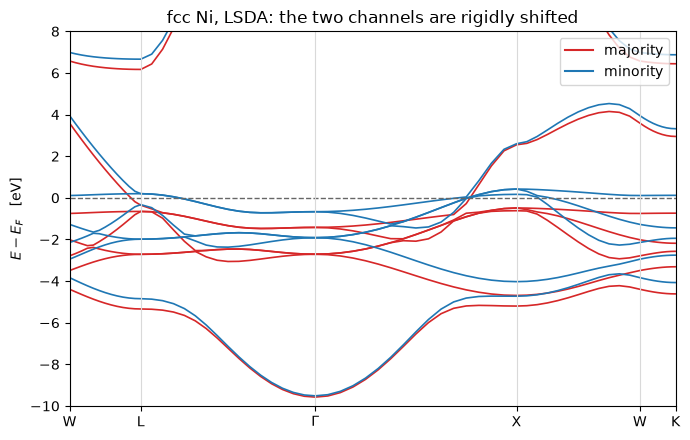

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from defumat.system.kpoints import KPoints

PATH = np.array([[0.5, 0.25, 0.75], [0.5, 0.5, 0.5], [0.0, 0.0, 0.0],
                 [0.0, 0.0, 1.0], [0.5, 0.25, 0.75], [0.375, 0.375, 0.75]])
COUNTS = np.array([12, 16, 16, 12, 8, 0])
LABELS = ["W", "L", r"$\Gamma$", "X", "W", "K"]

bands = nickel.get_bands(kpoints=KPoints.band_path(PATH, COUNTS, nickel.system.cell,
                                                   crystal=False), nbnd=9)
x = bands.path_length
levels = bands.eigenvalues_by_spin * RY_TO_EV - scf.fermi_energy * RY_TO_EV

fig, ax = plt.subplots(figsize=(7.0, 4.5))
for spin, (colour, label) in enumerate((("C3", "majority"), ("C0", "minority"))):
    ax.plot(x, levels[spin], color=colour, lw=1.2)
    ax.plot([], [], color=colour, label=label)
ax.axhline(0.0, color="0.4", ls="--", lw=1.0)
ticks = [x[i] for i in np.cumsum([0] + list(COUNTS[:-1]))]
for tick in ticks:
    ax.axvline(tick, color="0.85", lw=0.8)
ax.set(xticks=ticks, xticklabels=LABELS, xlim=(x[0], x[-1]), ylim=(-10.0, 8.0),
       ylabel=r"$E - E_F$   [eV]",
       title="fcc Ni, LSDA: the two channels are rigidly shifted")
ax.legend(loc="upper right")
fig.tight_layout()

## The same thing as a density of states

Two curves instead of one, plotted back to back. **The Fermi level is not per channel**: the
count whose root is $E_F$ is the sum over both, so a magnetic metal moves electrons from one
channel to the other until that single number is stationary, and the moment is the imbalance
that produces. The majority d states are full and lie below $E_F$; the minority d states
straddle it, which is also why nickel's Fermi surface is the complicated one.

N_up(E_F) = 5.3175   N_dw(E_F) = 4.6825   total = 10.0000   (10 valence electrons)
m from the density of states  +0.6351 mu_B
m from the self-consistent run +0.7280 mu_B   (on its own 4x4x4 grid)


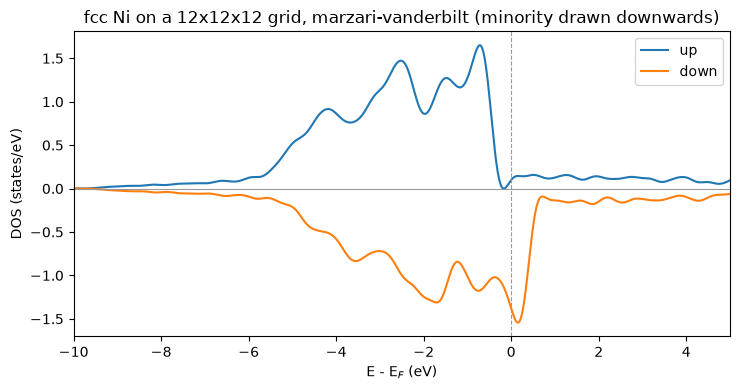

In [4]:
dos = nickel.get_dos(grid=(12, 12, 12))
fermi = dos.fermi_energy
up, down = (float(np.interp(fermi, dos.energies, dos.integrated[s])) for s in range(2))

fig, ax = plt.subplots(figsize=(7.5, 4.0))
dos.plot(ax=ax)
ax.set_xlim(-10.0, 5.0)
ax.set_title("fcc Ni on a 12x12x12 grid, %s (minority drawn downwards)" % dos.scheme)
fig.tight_layout()

print("N_up(E_F) = %.4f   N_dw(E_F) = %.4f   total = %.4f   (10 valence electrons)"
      % (up, down, up + down))
print("m from the density of states  %+.4f mu_B" % (up - down))
print("m from the self-consistent run %+.4f mu_B   (on its own 4x4x4 grid)"
      % scf.magnetization)

The two moments are not required to agree exactly and do not -- 0.635 against 0.728. They
are the same integral over two different k-grids, the self-consistent one on the coarser of
the two, and a moment is a difference of two numbers near five, so it inherits the sampling
error of both. The one to quote is the self-consistent value, which is the one the energy was
minimised with.

## What it refuses

**`occupations = 'fixed'` with two channels needs an integer `tot_magnetization`**, which is
`pw.x`'s rule, made at input here in QE's order. And what the residual solver cannot take is
a fixed occupation that cuts a **degenerate multiplet** -- a Hund's-rule atom, which is most
of what this combination is for: which member of the multiplet the eigensolver returns is
arbitrary, so the energy is not a function of the density and there is nothing for a Newton
step to converge on. It is diagnosed by name; the mixer is unaffected, and a *gapped*
fixed-occupation cell agrees between the two solvers to 5e-12 Ry.

---
The tests behind this notebook: `tests/regression/test_lsda.py`, which holds all eight
benchmarks -- their energies term by term, their magnetizations, their eigenvalues, the
shared Fermi level and the two-Fermi-level constrained variant, the density integrating to
the occupations, and the check that two equal channels reproduce the unpolarized answer --
and `tests/regression/test_isolated_atom.py`.